In [1]:
# Project Root

from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent

os.chdir(PROJECT_ROOT)

print(PROJECT_ROOT)

d:\IITG\Projects\audio_factor_disentanglement_v2


In [2]:
# Imports

import gc
import copy
import random
import time

import numpy as np
import pandas as pd

import torch

import matplotlib.pyplot as plt

from src.utils.config_loader import (
    load_yaml
)

from src.dataset.feature_loader import (
    build_dataloader
)

from src.models.factorized.factorized_vae import (
    FactorizedVAE
)

from src.losses.total_loss import (
    TotalLoss
)

from src.trainers.trainer import (
    Trainer
)

from src.trainers.memory_monitor import (
    MemoryMonitor
)

from src.trainers.beta_scheduler import (
    BetaScheduler
)

from src.trainers.checkpoint_manager import (
    CheckpointManager
)

In [3]:
# Seed

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

In [4]:
# Configs

model_cfg = load_yaml(

    PROJECT_ROOT
    /
    "configs"
    /
    "model_config.yaml"
)

train_cfg = load_yaml(

    PROJECT_ROOT
    /
    "configs"
    /
    "train_config.yaml"
)

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"
)

print(device)

cpu


In [5]:
# Merge Configs

merged_cfg = copy.deepcopy(
    model_cfg
)

merged_cfg[
    "staged_activation"
] = train_cfg[
    "staged_activation"
]

print(

    "staged_activation"

    in

    merged_cfg
)

True


In [6]:
# Memory Monitor

monitor = MemoryMonitor()

print(

    "RAM:",

    monitor.get_ram_gb(),

    "GB"
)

RAM: 0.2822608947753906 GB


In [7]:
# Validation Split Creator

import pandas as pd
import numpy as np

CSV_PATH = (

    PROJECT_ROOT
    /
    "data"
    /
    "metadata"
    /
    "feature_inventory_v2.csv"
)

VAL_RATIO = 0.15

SEED = 42

np.random.seed(SEED)

df = pd.read_csv(
    CSV_PATH
)

print()
print("Original Split Counts")
print(
    df["split"]
    .value_counts()
)

# ------------------------------------------
# Reset split
# ------------------------------------------

df["split"] = "train"

# ------------------------------------------
# Balanced speaker-condition split
# ------------------------------------------

val_indices = []

group_cols = []

if "speaker" in df.columns:
    group_cols.append(
        "speaker"
    )

if "condition" in df.columns:
    group_cols.append(
        "condition"
    )

groups = df.groupby(
    group_cols
)

for _, group in groups:

    n_val = max(

        1,

        int(
            len(group)
            *
            VAL_RATIO
        )
    )

    selected = np.random.choice(

        group.index,

        size=n_val,

        replace=False
    )

    val_indices.extend(
        selected
    )

df.loc[
    val_indices,
    "split"
] = "val"

# ------------------------------------------
# Save
# ------------------------------------------

df.to_csv(

    CSV_PATH,

    index=False
)

print()
print("Updated Split Counts")
print(
    df["split"]
    .value_counts()
)

print()
print(
    "Speaker x Split"
)
print(
    pd.crosstab(
        df["speaker"],
        df["split"]
    )
)

if "condition" in df.columns:

    print()
    print(
        "Condition x Split"
    )

    print(
        pd.crosstab(
            df["condition"],
            df["split"]
        )
    )

print()
print(
    f"Saved -> {CSV_PATH}"
)


Original Split Counts
split
train    265
val       46
Name: count, dtype: int64

Updated Split Counts
split
train    265
val       46
Name: count, dtype: int64

Speaker x Split
split    train  val
speaker            
s1         120   21
s2         145   25

Condition x Split
split      train  val
condition            
clean        110   19
noisy        155   27

Saved -> d:\IITG\Projects\audio_factor_disentanglement_v2\data\metadata\feature_inventory_v2.csv


In [8]:
# Dataloaders

train_loader = build_dataloader(

    PROJECT_ROOT,

    split="train"
)

val_loader = build_dataloader(

    PROJECT_ROOT,

    split="val"
)

print()

print(
    "Train Batches:",
    len(train_loader)
)

print(
    "Val Batches:",
    len(val_loader)
)


Train Batches: 265
Val Batches: 46


In [9]:
# Batch Inspection

batch = next(
    iter(train_loader)
)

for k,v in batch.items():

    if torch.is_tensor(v):

        print(
            k,
            tuple(v.shape)
        )

logmel (1, 80, 109)
mr_mag_256 (1, 129, 217)
mr_mag_512 (1, 257, 109)
mr_mag_1024 (1, 513, 55)
magnitude (1, 513, 109)
if (1, 513, 109)
modgd (1, 513, 109)
phase_sin (1, 513, 109)
phase_cos (1, 513, 109)
lengths (1,)


In [10]:
# Model

model = FactorizedVAE(
    model_cfg
).to(device)

loss_fn = TotalLoss(
    merged_cfg
)

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=train_cfg[
        "optimizer"
    ][
        "lr"
    ],

    weight_decay=train_cfg[
        "optimizer"
    ][
        "weight_decay"
    ]
)

print()

print(
    "Parameters:",
    sum(

        p.numel()

        for p in model.parameters()
    )
)


Parameters: 73217893


In [15]:
# Dry Run

batch_gpu = {}

for k,v in batch.items():

    if torch.is_tensor(v):

        batch_gpu[k] = (
            v.to(device)
        )

    else:

        batch_gpu[k] = v

start = time.time()

outputs = model(
    batch_gpu
)

loss_dict = loss_fn(

    outputs,

    batch_gpu
)

loss = loss_dict[
    "total"
]

loss.backward()

elapsed = (
    time.time()
    -
    start
)

print()

print(
    "Initial Loss:",
    float(loss)
)

print()

print(
    "Step Time:",
    round(
        elapsed,
        2
    ),
    "sec"
)

print()

print(
    "RAM:",
    monitor.get_ram_gb(),
    "GB"
)

del outputs
del loss

gc.collect()


Initial Loss: 8.06263256072998

Step Time: 7.97 sec

RAM: 6.009727478027344 GB


0

In [12]:
# Scheduler

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=train_cfg[
        "training"
    ][
        "epochs"
    ],

    eta_min=train_cfg[
        "scheduler"
    ][
        "min_lr"
    ]
)

In [13]:
# Trainer

trainer = Trainer(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    optimizer=optimizer,

    scheduler=scheduler,

    loss_fn=loss_fn,

    cfg=train_cfg,

    project_root=PROJECT_ROOT,

    device=device
)

d:\IITG\Projects\audio_factor_disentanglement_v2\src\trainers\trainer.py:132: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  GradScaler()
c:\Users\Dell\.conda\envs\betavae\Lib\site-packages\torch\cuda\amp\grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


In [14]:
# Dataset Split Check

inventory = pd.read_csv(

    PROJECT_ROOT
    /
    "data"
    /
    "metadata"
    /
    "feature_inventory_v2.csv"
)

print(

    inventory["split"]
    .value_counts()
)

split
train    265
val       46
Name: count, dtype: int64


In [16]:
from pathlib import Path

OUTPUT_DIR = (
    PROJECT_ROOT
    /
    "outputs"
)

CHECKPOINT_DIR = (
    OUTPUT_DIR
    /
    "checkpoints"
)

PLOT_DIR = (
    OUTPUT_DIR
    /
    "plots"
)

METRIC_DIR = (
    OUTPUT_DIR
    /
    "metrics"
)

LATENT_DIR = (
    OUTPUT_DIR
    /
    "latent_stats"
)

BETA_DIR = (
    OUTPUT_DIR
    /
    "beta_history"
)

LOG_DIR = (
    OUTPUT_DIR
    /
    "logs"
)

for d in [

    OUTPUT_DIR,
    CHECKPOINT_DIR,
    PLOT_DIR,
    METRIC_DIR,
    LATENT_DIR,
    BETA_DIR,
    LOG_DIR

]:

    d.mkdir(
        parents=True,
        exist_ok=True
    )

print("Directories Ready")

Directories Ready


In [17]:
from src.trainers.metrics_tracker import (
    MetricsTracker
)

from src.trainers.checkpoint_manager import (
    CheckpointManager
)

from src.trainers.latent_monitor import (
    LatentMonitor
)

from src.trainers.beta_scheduler import (
    BetaScheduler
)

tracker = MetricsTracker()

checkpoint_manager = (
    CheckpointManager(
        PROJECT_ROOT
    )
)

latent_monitor = (
    LatentMonitor(
        PROJECT_ROOT
    )
)

beta_scheduler = (
    BetaScheduler(
        PROJECT_ROOT
    )
)

print("Training Utilities Ready")

Training Utilities Ready


In [18]:
model = FactorizedVAE(
    model_cfg
).to(device)

loss_fn = TotalLoss(
    merged_cfg
)

print(
    f"Parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Parameters: 73,217,893


In [20]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=train_cfg[
        "optimizer"
    ]["lr"],

    weight_decay=train_cfg[
        "optimizer"
    ]["weight_decay"]
)

print(
    optimizer
)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0.0001
)


In [21]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=train_cfg[
        "training"
    ]["epochs"],

    eta_min=train_cfg[
        "scheduler"
    ]["min_lr"]
)

print(
    scheduler
)

In [22]:
history = {

    "train_loss": [],
    "val_loss": [],

    "reconstruction": [],
    "multires": [],

    "orthogonality": [],
    "tc": [],

    "content_kl": [],
    "speaker_kl": [],
    "environment_kl": [],
    "excitation_kl": [],
    "fidelity_kl": [],

    "lr": []
}

beta_history = []

latent_history = []

In [23]:
best_val = float("inf")

patience_counter = 0

start_epoch = 0

epochs = train_cfg[
    "training"
]["epochs"]

print(
    f"Epochs = {epochs}"
)

print(
    f"Train Batches = {len(train_loader)}"
)

print(
    f"Val Batches = {len(val_loader)}"
)

Epochs = 300
Train Batches = 265
Val Batches = 46


In [30]:
from tqdm import tqdm

def train_one_epoch(

    model,
    loader,
    loss_fn,
    optimizer,
    epoch

):

    model.train()

    tracker.reset()

    last_outputs = None

    for batch in tqdm(

        loader,

        leave=False

    ):

        batch = {

            k:
            (
                v.to(device)

                if torch.is_tensor(v)

                else v
            )

            for k,v in batch.items()
        }

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(
            batch
        )

        loss_dict = loss_fn(
            outputs,
            batch
        )

        loss = loss_dict[
            "total"
        ]

        loss.backward()

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            train_cfg[
                "gradient"
            ][
                "clip_norm"
            ]
        )

        optimizer.step()

        tracker.update(
            loss_dict
        )

        last_outputs = outputs

    metrics = tracker.averages()

    return metrics, last_outputs

In [31]:
@torch.no_grad()

def validate_one_epoch(

    model,
    loader,
    loss_fn

):

    model.eval()

    tracker.reset()

    for batch in loader:

        batch = {

            k:
            (
                v.to(device)

                if torch.is_tensor(v)

                else v
            )

            for k,v in batch.items()
        }

        outputs = model(
            batch
        )

        loss_dict = loss_fn(
            outputs,
            batch
        )

        tracker.update(
            loss_dict
        )

    return tracker.averages()

In [32]:
def get_grad_norm(model):

    total = 0.0

    for p in model.parameters():

        if p.grad is not None:

            total += (

                p.grad.norm()
                .item()
            )

    return total

In [33]:
def update_history(

    history,

    train_metrics,

    val_metrics,

    lr,

    grad_norm

):

    history[
        "train_loss"
    ].append(

        train_metrics[
            "total"
        ]
    )

    history[
        "val_loss"
    ].append(

        val_metrics[
            "total"
        ]
    )

    history[
        "lr"
    ].append(lr)

    history.setdefault(
        "grad_norm",
        []
    ).append(
        grad_norm
    )

    for key in train_metrics:

        if key not in history:

            history[key] = []

        history[key].append(

            train_metrics[key]
        )

In [34]:
LOSS_COMPONENTS = [

    "reconstruction",

    "multires",

    "phase_derivative",

    "phase_continuity",

    "von_mises",

    "content_kl",

    "speaker_kl",

    "environment_kl",

    "excitation_kl",

    "fidelity_kl",

    "orthogonality",

    "tc"
]

In [35]:
best_val_loss = float("inf")

patience_counter = 0

for epoch in range(

    start_epoch,

    epochs
):

    print()
    print(
        "=" * 80
    )

    print(
        f"Epoch "
        f"{epoch+1}/{epochs}"
    )

    print(
        "=" * 80
    )

    current_betas = (

        beta_scheduler
        .get_beta_dict(
            epoch
        )
    )

    print(
        "KL Betas:",
        current_betas
    )

    beta_history.append(
        current_betas
    )

    train_metrics, outputs = (

        train_one_epoch(

            model,

            train_loader,

            loss_fn,

            optimizer,

            epoch
        )
    )

    val_metrics = (

        validate_one_epoch(

            model,

            val_loader,

            loss_fn
        )
    )

    scheduler.step()

    grad_norm = (
        get_grad_norm(
            model
        )
    )

    update_history(

        history,

        train_metrics,

        val_metrics,

        optimizer.param_groups[
            0
        ]["lr"],

        grad_norm
    )

    latent_report = (

        latent_monitor.monitor(

            epoch,

            outputs[
                "latents"
            ]
        )
    )

    latent_history.append(
        latent_report
    )

    print()

    print(
        f"Train Loss : "
        f"{train_metrics['total']:.4f}"
    )

    print(
        f"Val Loss   : "
        f"{val_metrics['total']:.4f}"
    )

    print(
        f"Grad Norm  : "
        f"{grad_norm:.4f}"
    )

    print(
        f"LR         : "
        f"{optimizer.param_groups[0]['lr']:.8f}"
    )

    checkpoint_manager.save_latest(

        epoch,

        model,

        optimizer,

        scheduler,

        train_metrics
    )

    checkpoint_manager.save_epoch(

        epoch,

        model,

        optimizer,

        scheduler,

        train_metrics
    )

    checkpoint_manager.save_best(

        val_metrics["total"],

        epoch,

        model,

        optimizer,

        scheduler,

        train_metrics
    )

    if (

        val_metrics["total"]

        <

        best_val_loss
    ):

        best_val_loss = (
            val_metrics["total"]
        )

        patience_counter = 0

    else:

        patience_counter += 1

    if (

        train_cfg[
            "early_stopping"
        ][
            "enabled"
        ]

        and

        patience_counter
        >=
        train_cfg[
            "early_stopping"
        ][
            "patience"
        ]
    ):

        print()

        print(
            "EARLY STOPPING"
        )

        break

    gc.collect()

print()

print(
    "="*80
)

print(
    "TRAINING COMPLETE"
)

print(
    "="*80
)


Epoch 1/300
KL Betas: {'content': 0.0, 'speaker': 0.0, 'environment': 0.0, 'excitation': 0.0, 'fidelity': 0.0}



Train Loss : 5.4003
Val Loss   : 5.2864
Grad Norm  : 12.0334
LR         : 0.00049999

Epoch 2/300
KL Betas: {'content': 0.000125, 'speaker': 0.000375, 'environment': 0.0008750000000000001, 'excitation': 2.7924019108654782e-05, 'fidelity': 6.9810047771636955e-06}



Train Loss : 5.2264
Val Loss   : 5.2197
Grad Norm  : 3.6091
LR         : 0.00049995

Epoch 3/300
KL Betas: {'content': 0.00025, 'speaker': 0.00075, 'environment': 0.0017500000000000003, 'excitation': 7.324815475980207e-05, 'fidelity': 1.831203868995052e-05}



Train Loss : 5.2355
Val Loss   : 5.1571
Grad Norm  : 5.6415
LR         : 0.00049988

Epoch 4/300
KL Betas: {'content': 0.000375, 'speaker': 0.001125, 'environment': 0.002625, 'excitation': 0.00015265785151578787, 'fidelity': 3.8164462878946966e-05}



Train Loss : 5.1999
Val Loss   : 5.1561
Grad Norm  : 1.7918
LR         : 0.00049978

Epoch 5/300
KL Betas: {'content': 0.0005, 'speaker': 0.0015, 'environment': 0.0035000000000000005, 'excitation': 0.00028143385534379995, 'fidelity': 7.035846383594999e-05}


...


Train Loss : 5.1708
Val Loss   : 5.1516
Grad Norm  : 3.6675
LR         : 0.00026095

Epoch 147/300
KL Betas: {'content': 0.005, 'speaker': 0.015, 'environment': 0.035, 'excitation': 0.016083959896778497, 'fidelity': 0.004020989974194624}



Train Loss : 5.1696
Val Loss   : 5.1491
Grad Norm  : 1.1667
LR         : 0.00025834

Epoch 148/300
KL Betas: {'content': 0.005, 'speaker': 0.015, 'environment': 0.035, 'excitation': 0.014812909747525695, 'fidelity': 0.0037032274368814237}



Train Loss : 5.1670
Val Loss   : 5.1503
Grad Norm  : 1.3475
LR         : 0.00025573

Epoch 149/300
KL Betas: {'content': 0.005, 'speaker': 0.015, 'environment': 0.035, 'excitation': 0.013435661446562002, 'fidelity': 0.0033589153616405006}



Train Loss : 5.1686
Val Loss   : 5.1474
Grad Norm  : 1.3024
LR         : 0.00025311

Epoch 150/300
KL Betas: {'content': 0.005, 'speaker': 0.015, 'environment': 0.035, 'excitation': 0.011986127417882195, 'fidelity': 0.0029965318544705488}



Train Loss : 5.1688
Val Loss   : 5.1517
Grad Norm  : 0.6227
LR         : 0.00025050

EARLY STOPPING

TRAINING COMPLETE


In [36]:
metrics_df = pd.DataFrame(
    history
)

metrics_path = (

    METRIC_DIR
    /
    "training_metrics.csv"
)

metrics_df.to_csv(

    metrics_path,

    index=False
)

print(
    metrics_path
)

d:\IITG\Projects\audio_factor_disentanglement_v2\outputs\metrics\training_metrics.csv


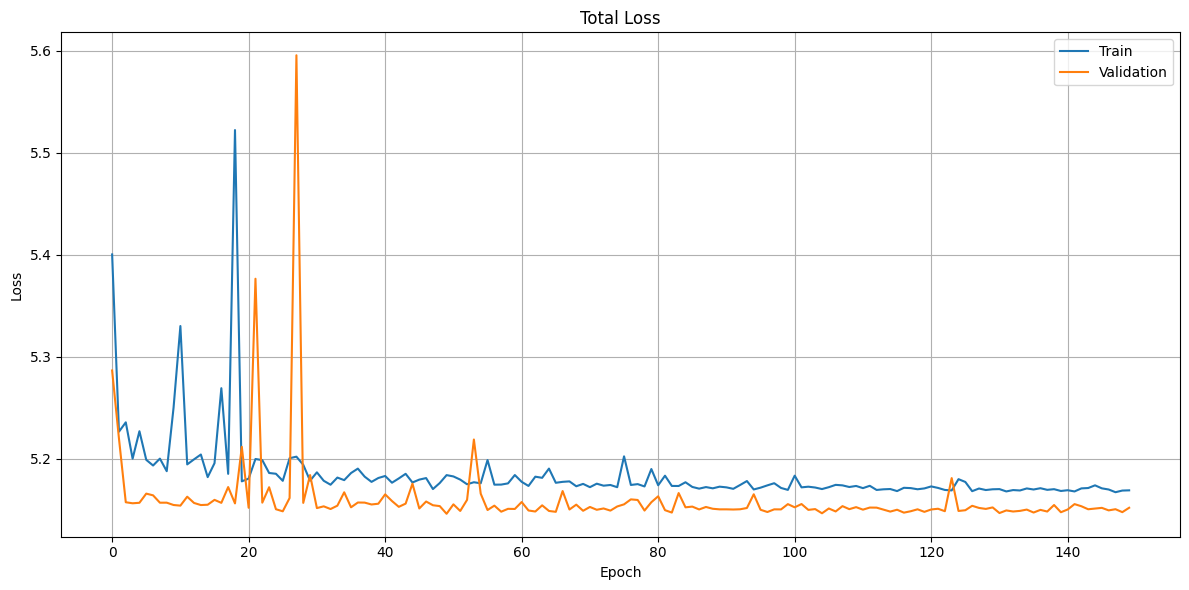

In [37]:
plt.figure(
    figsize=(12,6)
)

plt.plot(

    history[
        "train_loss"
    ],

    label="Train"
)

plt.plot(

    history[
        "val_loss"
    ],

    label="Validation"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Total Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    PLOT_DIR
    /
    "total_loss.png"
)

plt.show()

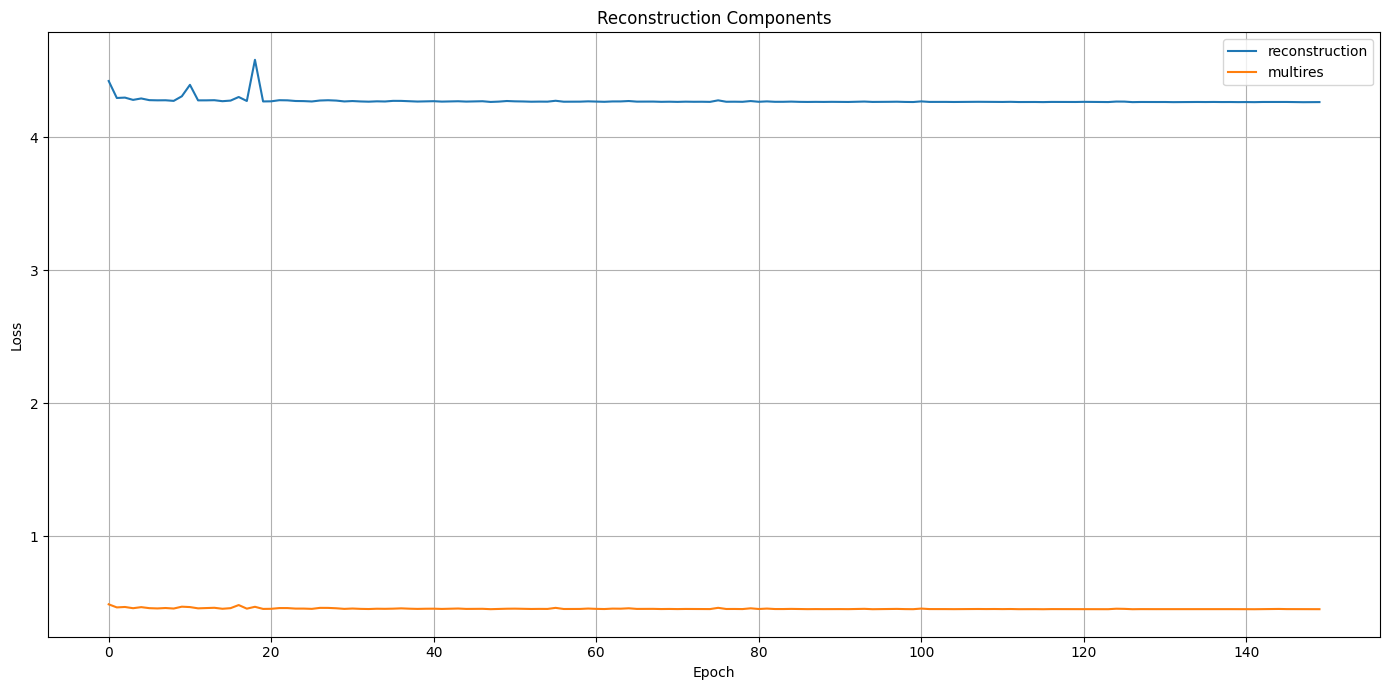

In [38]:
plt.figure(
    figsize=(14,7)
)

for key in [

    "reconstruction",

    "multires"

]:

    if key in history:

        plt.plot(

            history[key],

            label=key
        )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Reconstruction Components"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    PLOT_DIR
    /
    "reconstruction_components.png"
)

plt.show()

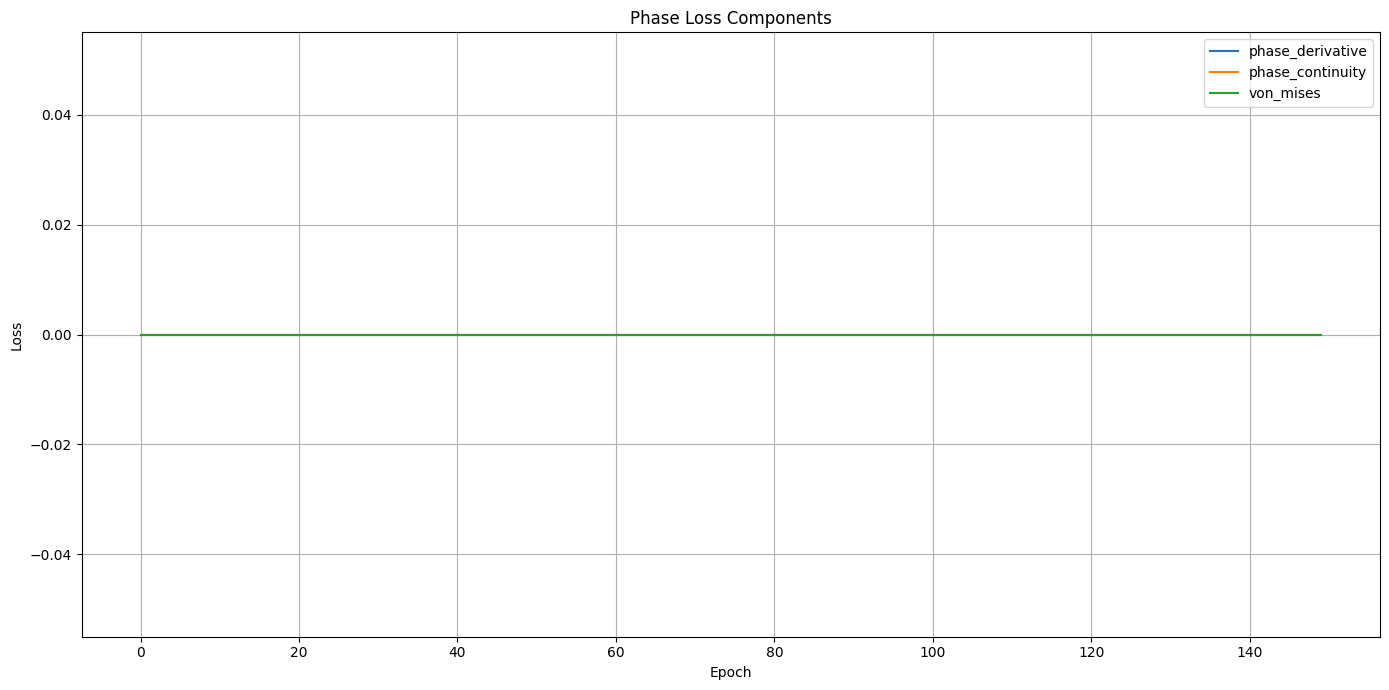

In [39]:
plt.figure(
    figsize=(14,7)
)

for key in [

    "phase_derivative",

    "phase_continuity",

    "von_mises"

]:

    if key in history:

        plt.plot(

            history[key],

            label=key
        )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Phase Loss Components"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    PLOT_DIR
    /
    "phase_losses.png"
)

plt.show()

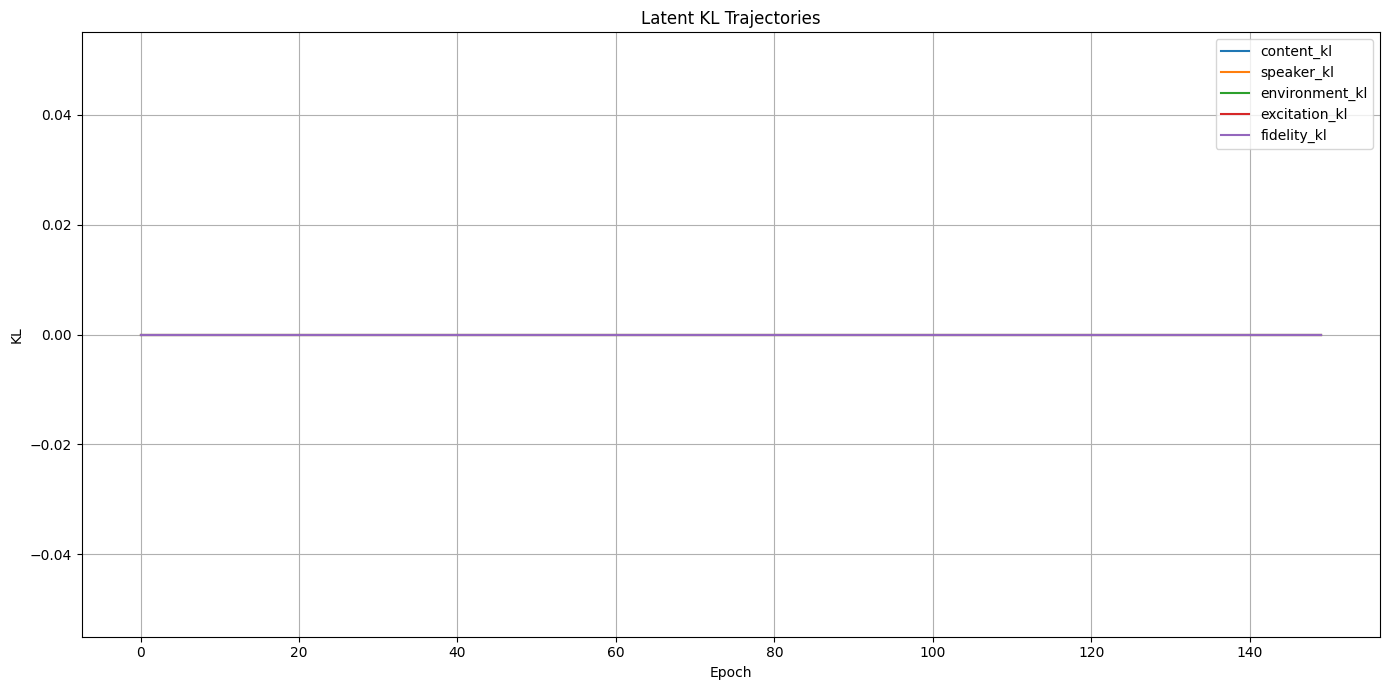

In [40]:
plt.figure(
    figsize=(14,7)
)

for key in [

    "content_kl",

    "speaker_kl",

    "environment_kl",

    "excitation_kl",

    "fidelity_kl"

]:

    if key in history:

        plt.plot(

            history[key],

            label=key
        )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "KL"
)

plt.title(
    "Latent KL Trajectories"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    PLOT_DIR
    /
    "kl_trajectories.png"
)

plt.show()

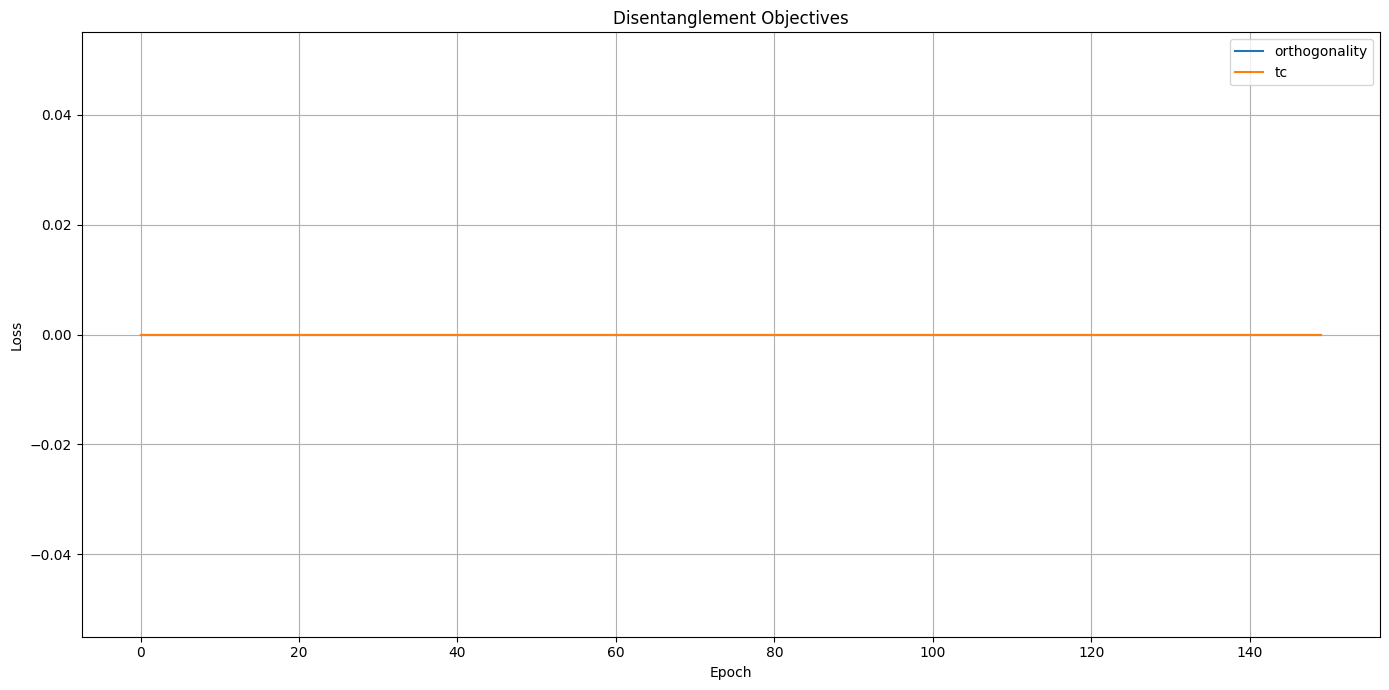

In [41]:
plt.figure(
    figsize=(14,7)
)

for key in [

    "orthogonality",

    "tc"

]:

    if key in history:

        plt.plot(

            history[key],

            label=key
        )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Disentanglement Objectives"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    PLOT_DIR
    /
    "disentanglement_losses.png"
)

plt.show()

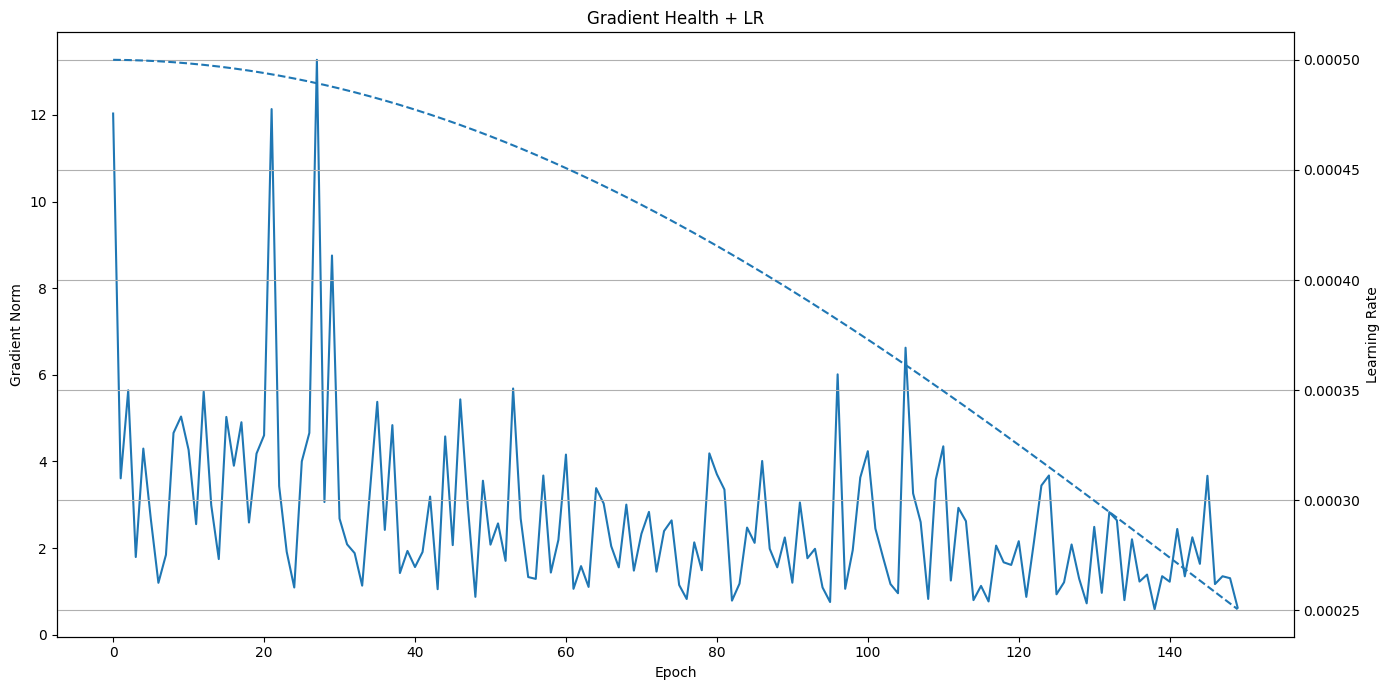

In [42]:
fig = plt.figure(
    figsize=(14,7)
)

ax1 = plt.gca()

ax1.plot(

    history[
        "grad_norm"
    ],

    label="Gradient Norm"
)

ax1.set_xlabel(
    "Epoch"
)

ax1.set_ylabel(
    "Gradient Norm"
)

ax2 = ax1.twinx()

ax2.plot(

    history[
        "lr"
    ],

    linestyle="--",

    label="Learning Rate"
)

ax2.set_ylabel(
    "Learning Rate"
)

plt.title(
    "Gradient Health + LR"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(

    PLOT_DIR
    /
    "gradient_lr.png"
)

plt.show()

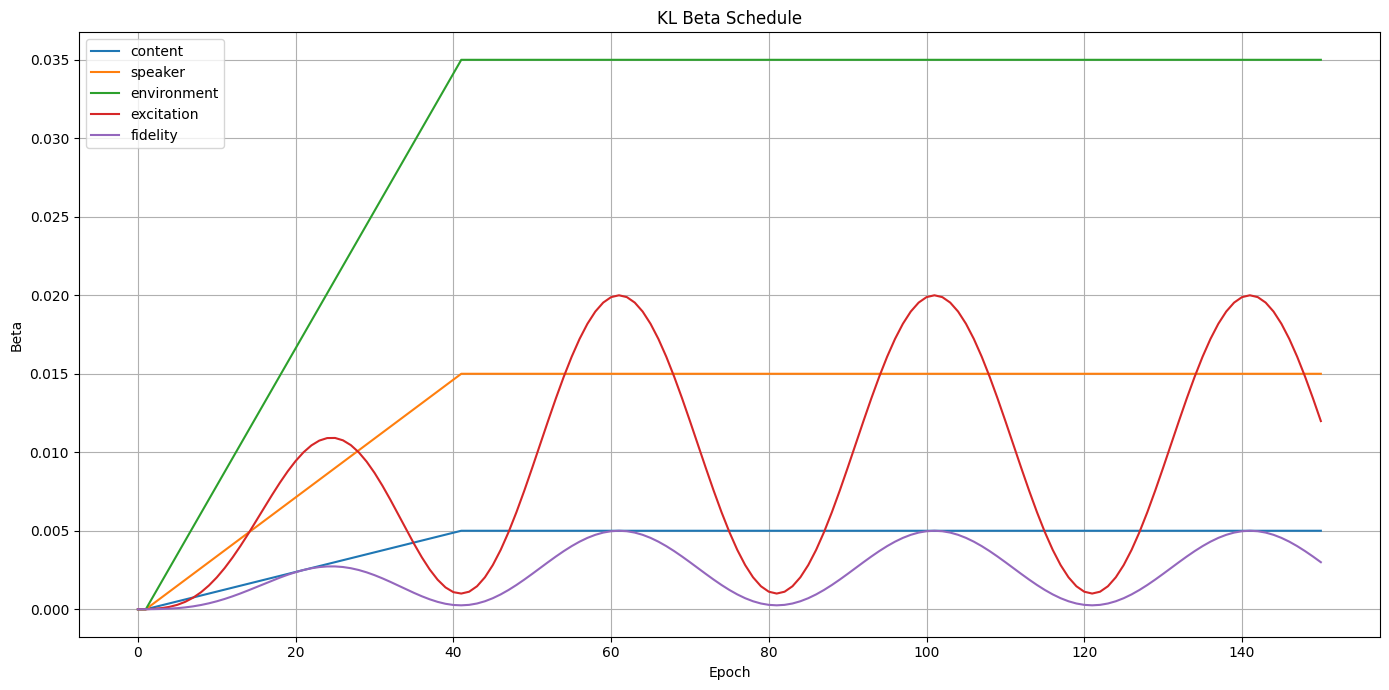

In [43]:
beta_df = pd.DataFrame(
    beta_history
)

plt.figure(
    figsize=(14,7)
)

for col in beta_df.columns:

    plt.plot(

        beta_df[col],

        label=col
    )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Beta"
)

plt.title(
    "KL Beta Schedule"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    PLOT_DIR
    /
    "beta_schedule.png"
)

plt.show()

beta_df.to_csv(

    BETA_DIR
    /
    "beta_history.csv",

    index=False
)

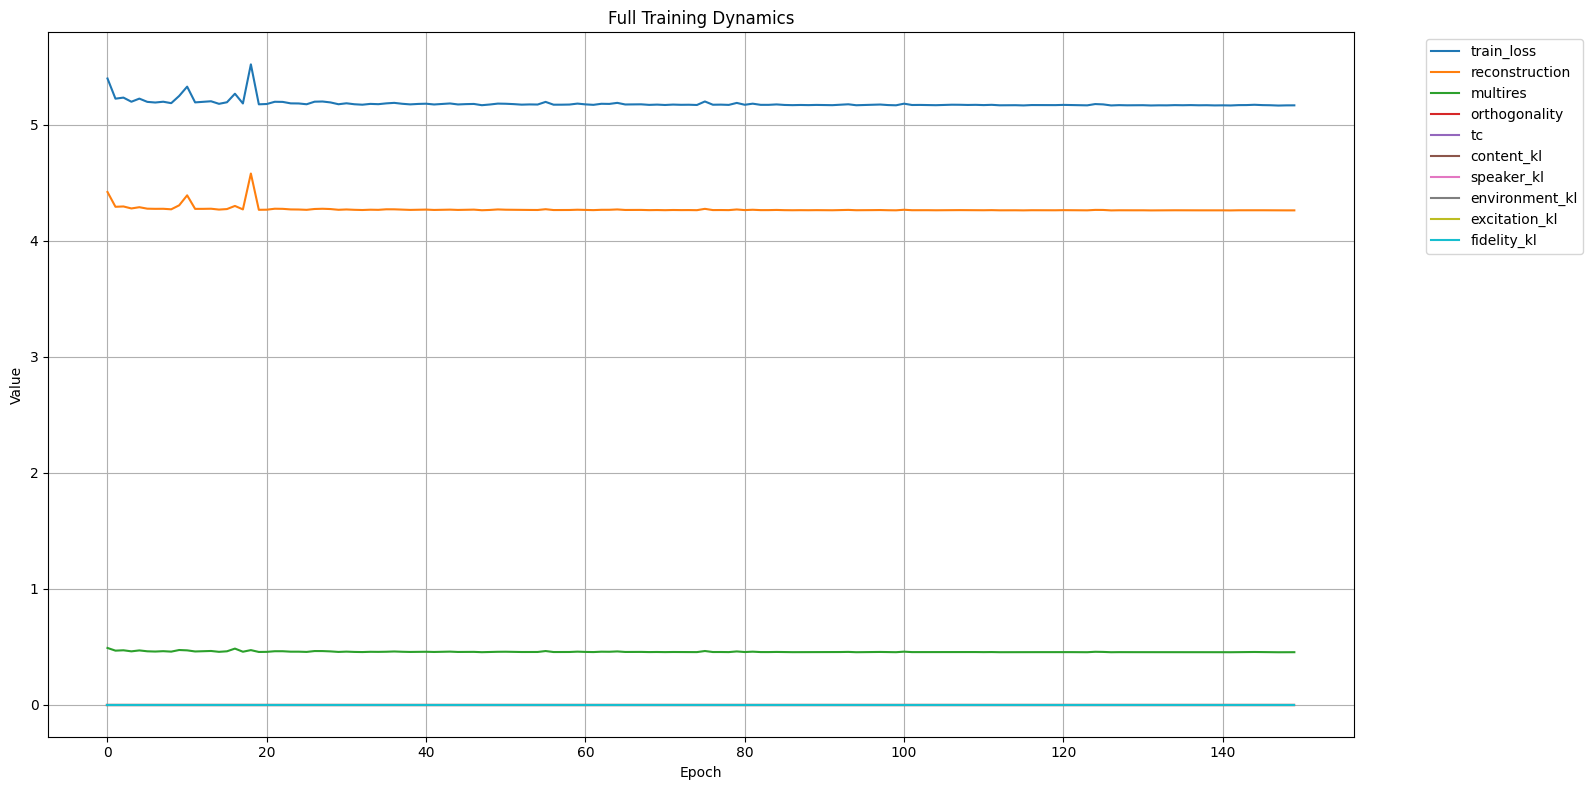

In [44]:
plt.figure(
    figsize=(16,8)
)

plot_keys = [

    "train_loss",

    "reconstruction",

    "multires",

    "orthogonality",

    "tc",

    "content_kl",

    "speaker_kl",

    "environment_kl",

    "excitation_kl",

    "fidelity_kl"
]

for key in plot_keys:

    if key in history:

        plt.plot(

            history[key],

            label=key
        )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Value"
)

plt.title(
    "Full Training Dynamics"
)

plt.legend(
    bbox_to_anchor=(1.05,1)
)

plt.grid(True)

plt.tight_layout()

plt.savefig(

    PLOT_DIR
    /
    "full_dynamics.png"
)

plt.show()

In [45]:
summary = pd.DataFrame({

    "Metric":[

        "Best Val Loss",

        "Final Train Loss",

        "Final Val Loss",

        "Final LR",

        "Epochs Completed"
    ],

    "Value":[

        best_val_loss,

        history["train_loss"][-1],

        history["val_loss"][-1],

        history["lr"][-1],

        len(
            history[
                "train_loss"
            ]
        )
    ]
})

display(summary)

summary.to_csv(

    METRIC_DIR
    /
    "final_summary.csv",

    index=False
)

,Metric,Value
0,Best Val Loss,5.145785
1,Final Train Loss,5.168795
2,Final Val Loss,5.151705
3,Final LR,0.000250
4,Epochs Completed,150.000000
